# Scenario Generation Analysis — Structure & Characteristics

This notebook studies the **raw scenario trees themselves** (price and
renewable-generation paths, tree topology, probabilities), independently of
how they later perform inside the optimization model. That downstream side —
solve time, objective value, DA commitments as a function of scenario count
and method — is already covered by `analises_results.ipynb` §14 and is not
repeated here.

**Data sources:**
- Raw scenario-tree JSON output, generated by `scentree-gen-remote`:
  `{same_ren,dif_ren}_scentree/scenariotree_<N>/results_<day>.json`
  (`dif_ren`: sc 50→300 step 10 × 30 days ≈ 780 files, 3.6GB;
  `same_ren`: sc 50→600 step 10 × 30 days ≈ 1680 files, 11GB).
- `results_batch_{same,dif}_ren.csv` in this repo — downstream metrics, for
  Phase 4 cross-referencing only.

**Plan:**
- **Phase 0** (this notebook, done below) — build a reusable extraction layer
  that reduces every raw JSON file to two tidy tables (topology/probability
  summary, and per-dataset-per-stage value statistics + forecast fidelity),
  without ever holding the full ~14.6GB corpus in memory at once.
- **Phase 1** — deep dive into one representative generation (fan charts,
  branching diagram, probability histogram).
- **Phase 2** — across scenario counts, same method: do moments/probability
  concentration stabilize as scenario count grows? Where are the diminishing
  returns?
- **Phase 3** — across methods (`same_ren` vs `dif_ren`) at matched scenario
  counts: topology, renewable-specific spread, forecast fidelity.
- **Phase 4** — tie Phase 2/3 findings back to `results_batch_*.csv` (solve
  time, objective, reduction ratio) to connect scenario-structure cause to
  optimization-outcome effect.

Phases 1–4 are left as section stubs below, to be filled in in a follow-up
session once Phase 0's output tables are reviewed.

## 0 · Imports & Setup

In [1]:
import json
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
print("Libraries loaded ✓")

Libraries loaded ✓


## 1 · Configuration

In [2]:
SCENTREE_ROOT = Path("/users/delfos/aina/secoem-VSS/scentree-gen-remote")
METHOD_DIRS = {
    "dif_ren": SCENTREE_ROOT / "dif_ren_scentree",
    "same_ren": SCENTREE_ROOT / "same_ren_scentree",
}

REPO_ROOT = Path(".").resolve()
SUMMARY_CSV = REPO_ROOT / "scenario_tree_summary.csv"
STAGE_STATS_CSV = REPO_ROOT / "scenario_tree_stage_stats.csv"

# Set False to force a full re-scan of the raw JSON corpus even if cached
# CSVs already exist (the scan is fast, ~3 min for ~2,460 files, but there's
# no reason to redo it on every notebook run).
USE_CACHE_IF_PRESENT = False

for name, path in METHOD_DIRS.items():
    print(f"{name}: {path}  (exists: {path.is_dir()})")

dif_ren: /users/delfos/aina/scentree-gen-remote/scentree-gen-remote/dif_ren_scentree  (exists: True)
same_ren: /users/delfos/aina/scentree-gen-remote/scentree-gen-remote/same_ren_scentree  (exists: True)


## Phase 0 · Extraction Layer

Each raw file holds a full scenario tree: `scenario_tree_data` (nS ×
nCols path values), `scenario_probabilities` (length nS), `tree` (node list
with `key=[stage, cluster_id]`, `parent_key`, `scenario_ids`),
`mapping_datasets_columns` (which columns belong to which market/dataset and
which stage), and `predicted_value` / `observed_value` /
`mean_value_scenario_tree` (a built-in point-forecast vs. realized-value
backtest).

We reduce each file to two rows types and discard the raw arrays immediately
after:

- **`tree_summary`** (one row per method × scenario-count-folder × day):
  tree topology (node/leaf counts, stages) and probability-mass concentration
  (entropy, effective number of scenarios = 1/Σp²).
- **`stage_stats`** (one row per method × scenario-count-folder × day ×
  dataset × stage): cross-scenario value statistics and forecast bias.
  Stats are computed **per column, across scenarios, then averaged across the
  columns in that stage** (not flattened together) — flattening would mix
  genuine scenario uncertainty with the diurnal shape of the stage's own time
  axis (e.g. DA's stage 1 spans all 96 quarter-hours of the day), which would
  inflate `value_std` with something that isn't uncertainty at all.

In [3]:
_SC_RE = re.compile(r"scenariotree_(\d+)$")
_DAY_RE = re.compile(r"results_(\d+)\.json$")


def discover_files(method_dirs=METHOD_DIRS):
    files = []
    for method, root in method_dirs.items():
        if not root.is_dir():
            continue
        for sc_dir in sorted(root.iterdir()):
            m = _SC_RE.search(sc_dir.name)
            if not m or not sc_dir.is_dir():
                continue
            sc_folder = int(m.group(1))
            for f in sorted(sc_dir.iterdir()):
                dm = _DAY_RE.search(f.name)
                if not dm:
                    continue
                files.append((method, sc_folder, int(dm.group(1)), f))
    return files


all_files = discover_files()
print(f"Discovered {len(all_files)} raw scenario-tree files.")
pd.DataFrame(all_files, columns=["method", "sc_folder", "day", "path"]) \
  .groupby("method")["sc_folder"].agg(["min", "max", "nunique"])

Discovered 2460 raw scenario-tree files.


,min,max,nunique
method,,,
dif_ren,50,300,26
same_ren,50,600,56


In [4]:
def topology_stats(tree):
    all_keys = {tuple(n["key"]) for n in tree}
    parent_keys = {tuple(n["parent_key"]) for n in tree if n["parent_key"] is not None}
    leaves = all_keys - parent_keys
    leaf_nodes = [n for n in tree if tuple(n["key"]) in leaves]
    stages = np.array([n["key"][0] for n in tree])
    stage_counts = np.bincount(stages)
    nonzero = stage_counts[stage_counts > 0]
    leaf_group_sizes = [len(n["scenario_ids"]) for n in leaf_nodes]
    return {
        "num_nodes": len(tree),
        "num_tree_stages": int(stages.max() + 1),
        "num_leaf_nodes": len(leaves),
        "avg_nodes_per_stage": float(nonzero.mean()),
        "max_nodes_per_stage": int(stage_counts.max()),
        "avg_leaf_group_size": float(np.mean(leaf_group_sizes)),
        "max_leaf_group_size": int(np.max(leaf_group_sizes)),
    }


def probability_stats(probs):
    p = np.asarray(probs, dtype=float)
    p = p[p > 0]
    n = len(p)
    entropy = float(-(p * np.log(p)).sum())
    return {
        "prob_min": float(p.min()),
        "prob_max": float(p.max()),
        "prob_std": float(p.std()),
        "prob_entropy_norm": entropy / np.log(n) if n > 1 else np.nan,
        "effective_num_scenarios": float(1.0 / np.sum(p ** 2)),
    }

In [5]:
def _weighted_col_stats(sub, w, qs=(0.10, 0.50, 0.90)):
    col_mean = w @ sub
    col_var = w @ (sub - col_mean) ** 2
    order = np.argsort(sub, axis=0)
    cw = np.cumsum(w[order], axis=0)
    q_vals = {}
    for q in qs:
        idx = np.array([np.searchsorted(cw[:, c], q) for c in range(sub.shape[1])])
        idx = np.clip(idx, 0, sub.shape[0] - 1)
        q_vals[q] = sub[order[idx, np.arange(sub.shape[1])], np.arange(sub.shape[1])]
    return col_mean, np.sqrt(np.clip(col_var, 0, None)), q_vals


def stage_rows(d, method, sc_folder, day):
    data = np.asarray(d["scenario_tree_data"], dtype=float)
    probs = np.asarray(d["scenario_probabilities"], dtype=float)
    w = probs / probs.sum()
    mean_tree = np.asarray(d["mean_value_scenario_tree"], dtype=float)
    predicted = np.asarray(d["predicted_value"], dtype=float)
    observed = np.asarray(d["observed_value"], dtype=float)

    rows = []
    for block in d["mapping_datasets_columns"]:
        dataset = block["dataset"]
        cols = np.asarray(block["columns"])
        stage_ids = np.asarray(block["stage_ids"])
        for stage in np.unique(stage_ids):
            stage_cols = cols[stage_ids == stage]
            sub = data[:, stage_cols]
            col_mean, col_std, q_vals = _weighted_col_stats(sub, w)
            obs, mt, pr = observed[stage_cols], mean_tree[stage_cols], predicted[stage_cols]
            rows.append({
                "method": method, "sc_folder": sc_folder, "day": day,
                "dataset": dataset, "stage": int(stage), "n_columns": len(stage_cols),
                "value_mean": float(col_mean.mean()), "value_std": float(col_std.mean()),
                "value_p10": float(q_vals[0.10].mean()), "value_p50": float(q_vals[0.50].mean()),
                "value_p90": float(q_vals[0.90].mean()),
                "mean_tree_value": float(mt.mean()), "predicted_value": float(pr.mean()),
                "observed_value": float(obs.mean()),
                "bias_tree": float(mt.mean() - obs.mean()), "bias_pred": float(pr.mean() - obs.mean()),
            })
    return rows


def summarize_file(method, sc_folder, day, path):
    with open(path) as fh:
        d = json.load(fh)[0]
    summary = {
        "method": method, "sc_folder": sc_folder, "day": day,
        "num_scenarios": d["num_scenarios"], "num_stages": d["num_stages"],
        "in_sample_prediction": d["in_sample_prediction"], "path": str(path),
    }
    summary.update(topology_stats(d["tree"]))
    summary.update(probability_stats(d["scenario_probabilities"]))
    return summary, stage_rows(d, method, sc_folder, day)

In [6]:
def build_tables(files, progress_every=300):
    summaries, all_stage_rows = [], []
    for i, (method, sc_folder, day, path) in enumerate(files):
        try:
            s, rows = summarize_file(method, sc_folder, day, path)
        except Exception as e:
            s = {"method": method, "sc_folder": sc_folder, "day": day,
                 "path": str(path), "error": f"{type(e).__name__}: {e}"}
            rows = []
        summaries.append(s)
        all_stage_rows.extend(rows)
        if progress_every and (i + 1) % progress_every == 0:
            print(f"  processed {i + 1}/{len(files)} files")
    return pd.DataFrame(summaries), pd.DataFrame(all_stage_rows)


if USE_CACHE_IF_PRESENT and SUMMARY_CSV.exists() and STAGE_STATS_CSV.exists():
    print("Loading cached extraction from CSV...")
    tree_summary = pd.read_csv(SUMMARY_CSV)
    stage_stats = pd.read_csv(STAGE_STATS_CSV)
else:
    print(f"Extracting {len(all_files)} files (raw arrays discarded per-file, not held in memory)...")
    tree_summary, stage_stats = build_tables(all_files)
    tree_summary.to_csv(SUMMARY_CSV, index=False)
    stage_stats.to_csv(STAGE_STATS_CSV, index=False)
    print(f"Saved {SUMMARY_CSV.name} ({len(tree_summary)} rows) and {STAGE_STATS_CSV.name} ({len(stage_stats)} rows).")

Loading cached extraction from CSV...


### Phase 0 sanity checks

In [7]:
n_errors = tree_summary["error"].notna().sum() if "error" in tree_summary.columns else 0
print(f"tree_summary: {len(tree_summary)} rows, {n_errors} failed files")
print(f"stage_stats:  {len(stage_stats)} rows")
display(tree_summary.groupby("method")[["sc_folder", "day"]].nunique())
display(tree_summary.groupby("method")[
    ["num_nodes", "num_tree_stages", "effective_num_scenarios", "prob_max"]
].mean().round(2))

tree_summary: 2460 rows, 0 failed files
stage_stats:  247620 rows


,sc_folder,day
method,,
dif_ren,26,30
same_ren,56,30


,num_nodes,num_tree_stages,effective_num_scenarios,prob_max
method,,,,
dif_ren,8330.24,103.0,104.40,0.04
same_ren,2391.03,31.0,28.05,0.12


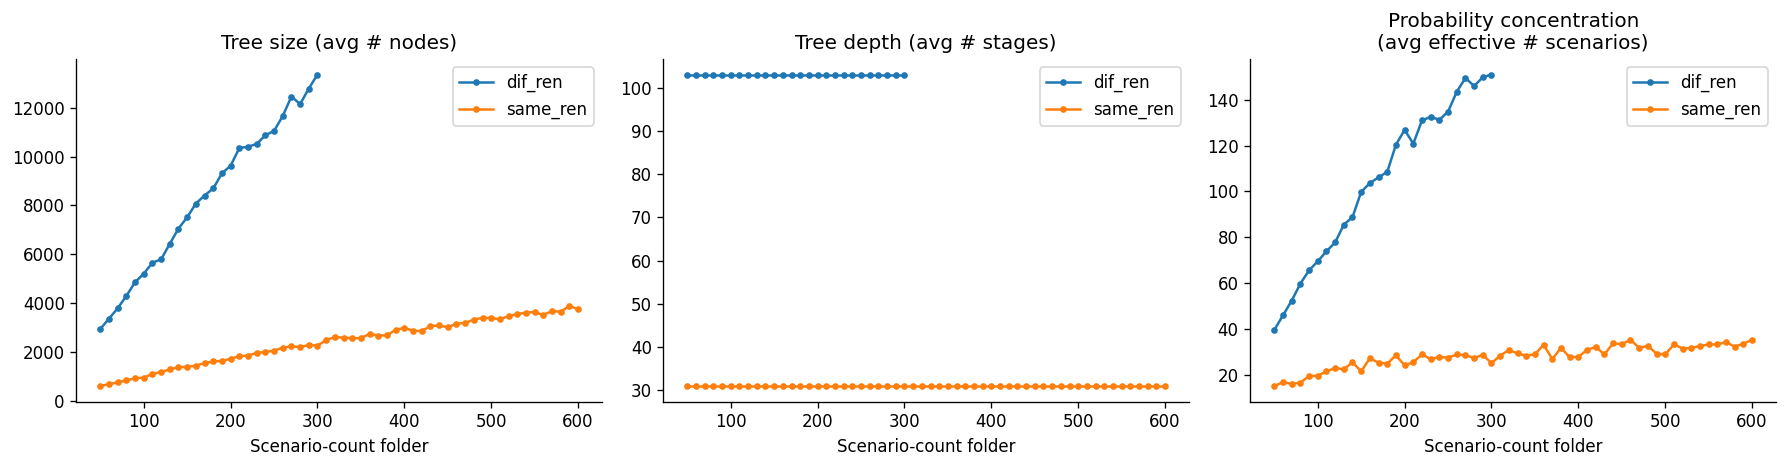

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
agg = tree_summary.groupby(["method", "sc_folder"]).mean(numeric_only=True).reset_index()
for method, sub in agg.groupby("method"):
    axes[0].plot(sub["sc_folder"], sub["num_nodes"], marker="o", ms=3, label=method)
    axes[1].plot(sub["sc_folder"], sub["num_tree_stages"], marker="o", ms=3, label=method)
    axes[2].plot(sub["sc_folder"], sub["effective_num_scenarios"], marker="o", ms=3, label=method)

axes[0].set_title("Tree size (avg # nodes)")
axes[1].set_title("Tree depth (avg # stages)")
axes[2].set_title("Probability concentration\n(avg effective # scenarios)")
for ax in axes:
    ax.set_xlabel("Scenario-count folder")
    ax.legend()
plt.tight_layout()
plt.show()

**Reading this chart:** `dif_ren` builds a much deeper, bigger tree at
every scenario count (it branches wind/PV every 15 minutes instead of hourly
blocks), and keeps probability mass close to uniform after reduction.
`same_ren` produces a shallower tree but concentrates probability far more
sharply onto a handful of scenarios — i.e. its reduction step is doing
more of the "compression" work than its coarser tree structure. This is the
extraction layer's first substantive finding and the natural entry point for
Phase 3.

## Phase 1 · Within one generation (deep dive)

Picks one representative `(sc_folder, day)` present in both methods and
inspects the raw tree directly: fan charts for a price dataset (`DA`) and a
renewable dataset (`WP`), the tree's actual branching shape stage-by-stage,
and the post-reduction probability distribution.

In [9]:
def load_raw_tree(method, sc_folder, day):
    path = tree_summary.query("method == @method and sc_folder == @sc_folder and day == @day")["path"].iloc[0]
    with open(path) as fh:
        return json.load(fh)[0]


EXAMPLE_SC, EXAMPLE_DAY = 100, 1
raw_trees = {m: load_raw_tree(m, EXAMPLE_SC, EXAMPLE_DAY) for m in METHOD_DIRS}
{m: (d["num_scenarios"], d["num_stages"], len(d["tree"])) for m, d in raw_trees.items()}

{'dif_ren': (100, 102, 4967), 'same_ren': (100, 30, 1082)}

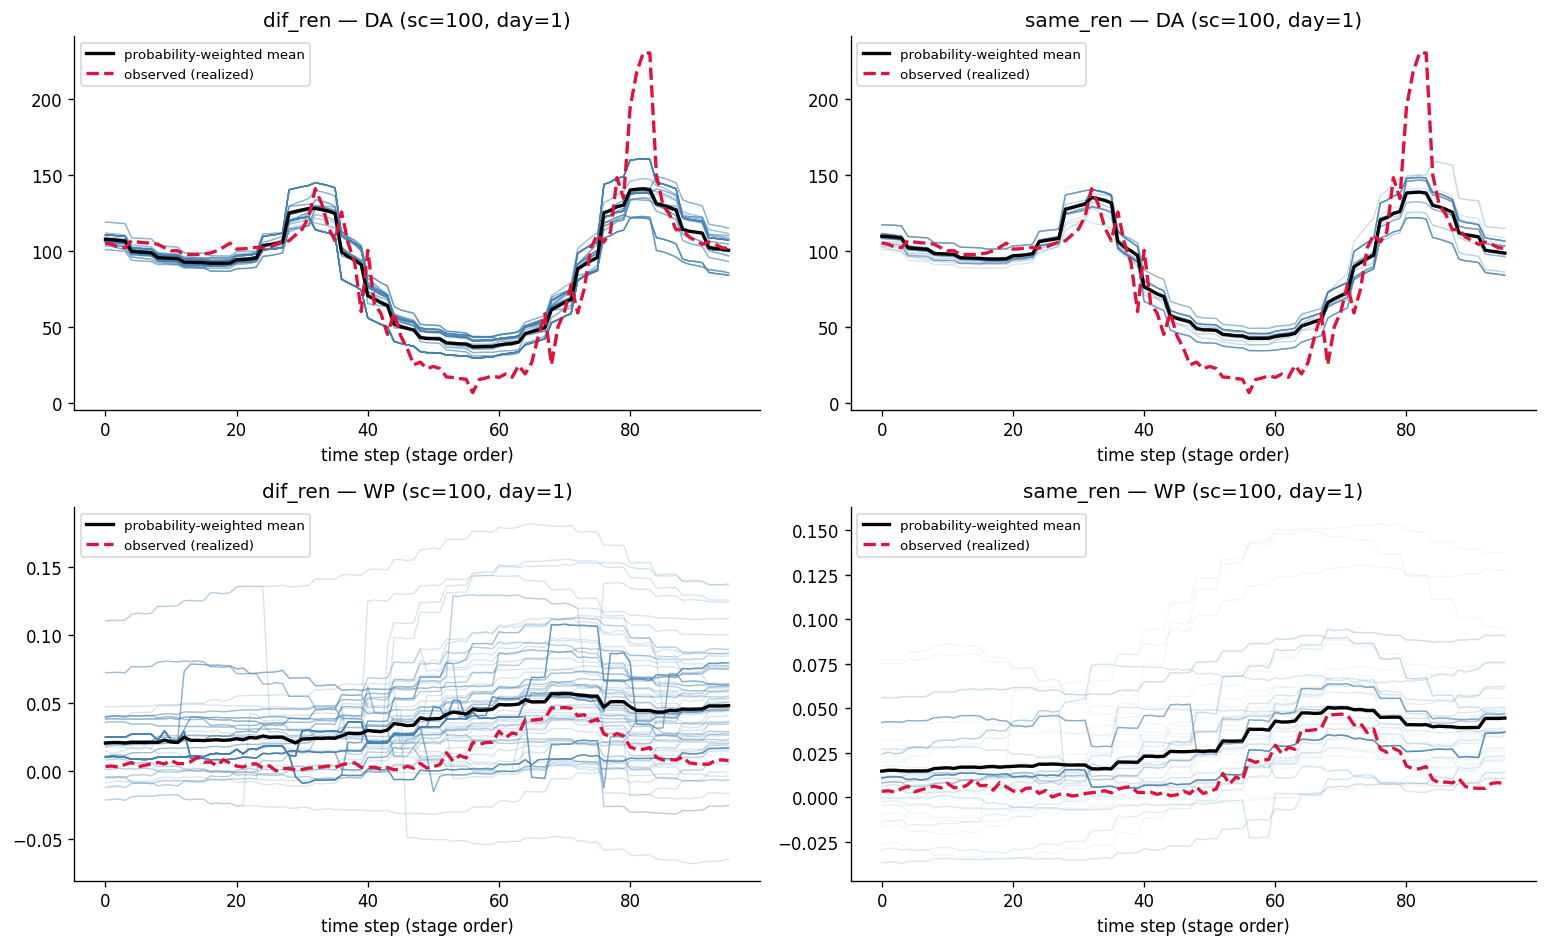

In [10]:
def dataset_block(d, dataset):
    return next(b for b in d["mapping_datasets_columns"] if b["dataset"] == dataset)


def fan_chart(ax, d, dataset, title):
    block = dataset_block(d, dataset)
    cols = np.asarray(block["columns"])
    stages = np.asarray(block["stage_ids"])
    order = np.argsort(stages, kind="stable")
    cols = cols[order]

    data = np.asarray(d["scenario_tree_data"], dtype=float)[:, cols]
    probs = np.asarray(d["scenario_probabilities"], dtype=float)
    mean_tree = np.asarray(d["mean_value_scenario_tree"], dtype=float)[cols]
    observed = np.asarray(d["observed_value"], dtype=float)[cols]

    x = np.arange(len(cols))
    alpha = 0.05 + 0.5 * (probs / probs.max())
    for s in range(data.shape[0]):
        ax.plot(x, data[s], color="steelblue", alpha=float(alpha[s]), lw=0.8)
    ax.plot(x, mean_tree, color="black", lw=2, label="probability-weighted mean")
    ax.plot(x, observed, color="crimson", lw=2, ls="--", label="observed (realized)")
    ax.set_title(title)
    ax.set_xlabel("time step (stage order)")
    ax.legend(fontsize=8)


fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, dataset in enumerate(["DA", "WP"]):
    for col, method in enumerate(METHOD_DIRS):
        fan_chart(axes[row, col], raw_trees[method], dataset,
                  f"{method} — {dataset} (sc={EXAMPLE_SC}, day={EXAMPLE_DAY})")
plt.tight_layout()
plt.show()

Column order within `WP`/`PV` isn't a simple time sequence in the raw
JSON (columns for the two datasets are interleaved and non-contiguous), so
the x-axis above is "columns sorted by stage index," which preserves the
tree's own resolution structure but shouldn't be read as calendar
quarter-hours the way the `DA` x-axis can.

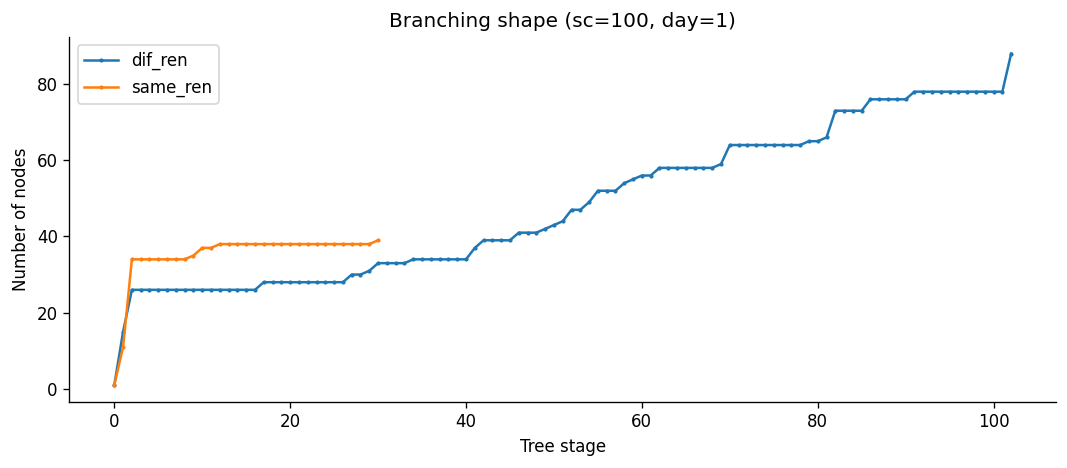

In [11]:
def nodes_per_stage(d):
    stages = np.array([n["key"][0] for n in d["tree"]])
    counts = np.bincount(stages)
    return np.arange(len(counts)), counts


fig, ax = plt.subplots(figsize=(9, 4))
for method, d in raw_trees.items():
    x, y = nodes_per_stage(d)
    ax.plot(x, y, marker=".", ms=3, label=method)
ax.set_xlabel("Tree stage")
ax.set_ylabel("Number of nodes")
ax.set_title(f"Branching shape (sc={EXAMPLE_SC}, day={EXAMPLE_DAY})")
ax.legend()
plt.tight_layout()
plt.show()

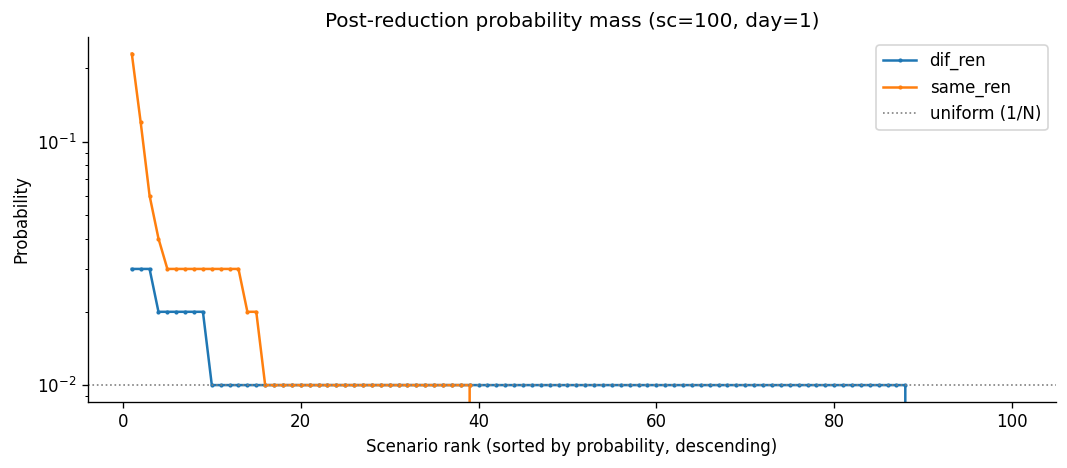

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
for method, d in raw_trees.items():
    p = np.sort(np.asarray(d["scenario_probabilities"]))[::-1]
    ax.plot(np.arange(1, len(p) + 1), p, marker=".", ms=3, label=method)
ax.axhline(1 / EXAMPLE_SC, color="grey", ls=":", lw=1, label="uniform (1/N)")
ax.set_xlabel("Scenario rank (sorted by probability, descending)")
ax.set_ylabel("Probability")
ax.set_yscale("log")
ax.set_title(f"Post-reduction probability mass (sc={EXAMPLE_SC}, day={EXAMPLE_DAY})")
ax.legend()
plt.tight_layout()
plt.show()

**Reading this generation:** `dif_ren`'s branching climbs steadily
through the ~100 renewable stages, so most scenarios stay distinguishable all
the way to the end (probability curve close to flat, near-uniform). `same_ren`
front-loads far less branching, so its probability curve has a steep head — a
handful of scenarios each carry several original fan paths, which is exactly
what "effective # scenarios ≈ 12/100" (see Phase 0/3) looks like at the
single-tree level rather than as a corpus average.

## Phase 2 · Across scenario counts, same method

Uses `stage_stats` averaged over all 30 days to check whether per-dataset
statistics stabilize as scenario count grows, and estimates a "stabilizes at"
scenario count per (method, dataset) — the point beyond which the average
cross-scenario standard deviation changes by less than 5% at every larger
count sampled.

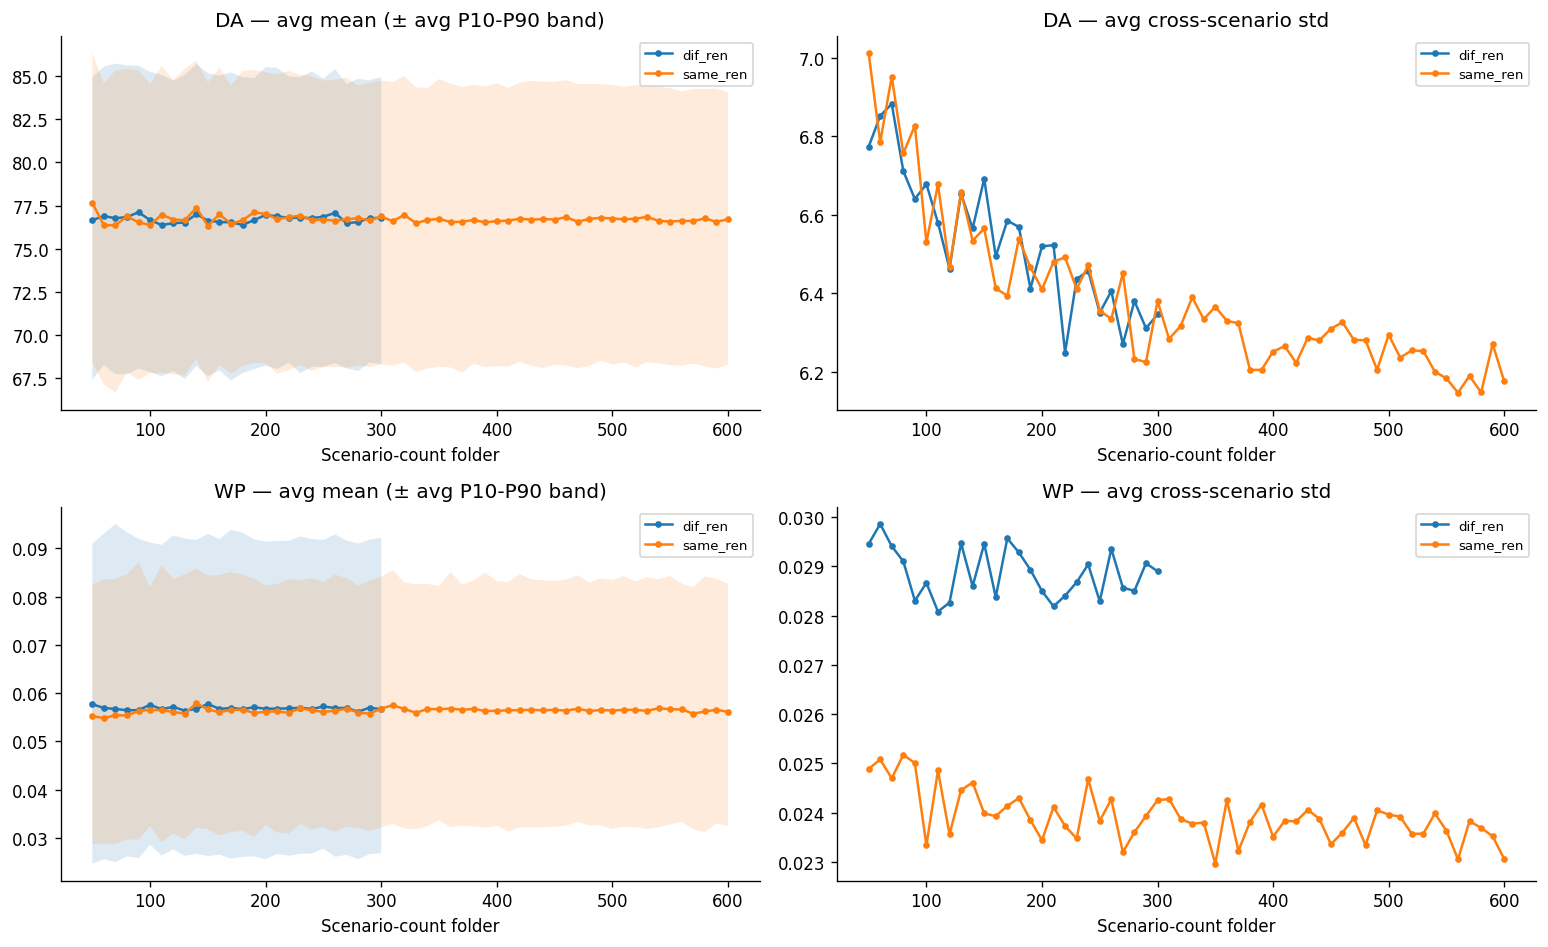

In [13]:
FOCUS_DATASETS = ["DA", "WP"]
day_agg = stage_stats[stage_stats["dataset"].isin(FOCUS_DATASETS)] \
    .groupby(["method", "dataset", "sc_folder"]) \
    .agg(value_mean=("value_mean", "mean"),
         value_std=("value_std", "mean"),
         value_p10=("value_p10", "mean"),
         value_p90=("value_p90", "mean")) \
    .reset_index()

fig, axes = plt.subplots(len(FOCUS_DATASETS), 2, figsize=(13, 4 * len(FOCUS_DATASETS)))
for row, dataset in enumerate(FOCUS_DATASETS):
    for method, sub in day_agg[day_agg["dataset"] == dataset].groupby("method"):
        sub = sub.sort_values("sc_folder")
        axes[row, 0].plot(sub["sc_folder"], sub["value_mean"], marker="o", ms=3, label=method)
        axes[row, 0].fill_between(sub["sc_folder"], sub["value_p10"], sub["value_p90"], alpha=0.15)
        axes[row, 1].plot(sub["sc_folder"], sub["value_std"], marker="o", ms=3, label=method)
    axes[row, 0].set_title(f"{dataset} — avg mean (± avg P10-P90 band)")
    axes[row, 1].set_title(f"{dataset} — avg cross-scenario std")
    for ax in axes[row]:
        ax.set_xlabel("Scenario-count folder")
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [14]:
def stability_threshold(sub, col, tol=0.05):
    sub = sub.sort_values("sc_folder").reset_index(drop=True)
    vals = sub[col].values
    changes = np.abs(np.diff(vals)) / (np.abs(vals[:-1]) + 1e-9)
    for i in range(len(changes)):
        if np.all(changes[i:] < tol):
            return int(sub["sc_folder"].iloc[i])
    return None


rows = []
for dataset in FOCUS_DATASETS:
    for method, sub in day_agg[day_agg["dataset"] == dataset].groupby("method"):
        rows.append({
            "method": method, "dataset": dataset,
            "stabilizes_at_sc_folder (avg std within 5% for all larger counts)":
                stability_threshold(sub, "value_std"),
        })
pd.DataFrame(rows)

,method,dataset,stabilizes_at_sc_folder (avg std within 5% for all larger counts)
0,dif_ren,DA,50
1,same_ren,DA,50
2,dif_ren,WP,50
3,same_ren,WP,360


**Reading this:** if a (method, dataset) row shows a scenario count
well below the maximum sampled, pushing further (e.g. `same_ren` past 300,
or `dif_ren` past 200) is mostly adding redundant scenarios rather than new
information for that dataset. If it shows `None`, the average std hadn't
settled within 5% by the largest count tested in this corpus.

## Phase 3 · Across methods (`same_ren` vs `dif_ren`)

Compares the two methods only over their **overlapping** scenario-count range
(`dif_ren` only goes up to 300) so the comparison isn't confounded by one
method simply having more scenario-count samples than the other.

In [15]:
COMMON_SC = sorted(set(tree_summary.query("method == 'dif_ren'")["sc_folder"]) &
                    set(tree_summary.query("method == 'same_ren'")["sc_folder"]))
print(f"{len(COMMON_SC)} common scenario-count folders, range {COMMON_SC[0]}-{COMMON_SC[-1]}")

topo_cmp = tree_summary[tree_summary["sc_folder"].isin(COMMON_SC)] \
    .groupby("method")[["num_nodes", "num_tree_stages", "effective_num_scenarios",
                         "prob_max", "avg_leaf_group_size"]] \
    .mean().round(2)
topo_cmp

26 common scenario-count folders, range 50-300


,num_nodes,num_tree_stages,effective_num_scenarios,prob_max,avg_leaf_group_size
method,,,,,
dif_ren,8330.24,103.0,104.40,0.04,1.16
same_ren,1529.84,31.0,24.08,0.13,2.42


In [16]:
method_cmp = stage_stats[stage_stats["sc_folder"].isin(COMMON_SC)] \
    .groupby(["dataset", "method"]) \
    .agg(value_std=("value_std", "mean"),
         abs_bias_tree=("bias_tree", lambda x: x.abs().mean()),
         abs_bias_pred=("bias_pred", lambda x: x.abs().mean())) \
    .round(3)
method_cmp

value_std  abs_bias_tree  abs_bias_pred
dataset method                                           
DA      dif_ren       6.531         14.215         14.162
        same_ren      6.531         14.076         14.162
IB_DOWN dif_ren      21.226         12.630         12.599
        same_ren     18.439         12.654         12.599
IB_UP   dif_ren      18.481         10.306         10.244
        same_ren     16.043         10.341         10.244
IM1     dif_ren      16.312         14.767         14.694
        same_ren     16.321         14.748         14.694
IM2     dif_ren      16.255         13.314         13.269
        same_ren     16.271         13.350         13.269
IM3     dif_ren      20.625         17.073         16.945
        same_ren     19.645         17.051         16.945
PV      dif_ren       0.008          0.010          0.010
        same_ren      0.007          0.010          0.010
RM      dif_ren       3.447          2.445          2.582
        same_ren      3.432          2.471          2.582
WP      dif_ren       0.029          0.032          0.032
        same_ren      0.024          0.032          0.032

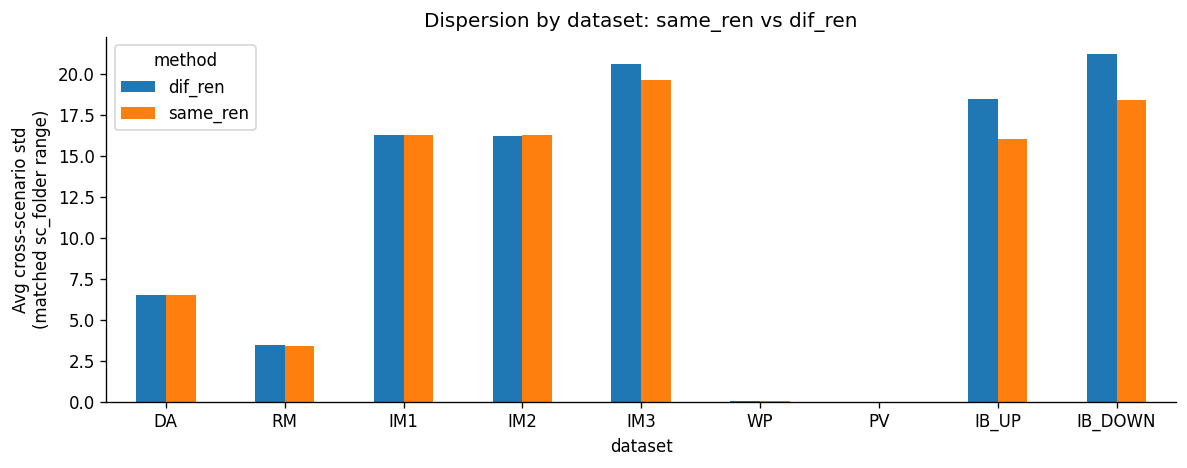

In [17]:
pivot_std = stage_stats[stage_stats["sc_folder"].isin(COMMON_SC)] \
    .groupby(["dataset", "method"])["value_std"].mean().unstack()
pivot_std = pivot_std.reindex(["DA", "RM", "IM1", "IM2", "IM3", "WP", "PV", "IB_UP", "IB_DOWN"])

fig, ax = plt.subplots(figsize=(10, 4))
pivot_std.plot(kind="bar", ax=ax)
ax.set_ylabel("Avg cross-scenario std\n(matched sc_folder range)")
ax.set_title("Dispersion by dataset: same_ren vs dif_ren")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

**Reading this:** the topology gap (nodes/stages/probability
concentration) is large and consistent across the whole overlap range, not
just at `sc=100`. If `WP`/`PV` dispersion (`value_std`) is *not* much larger
for `dif_ren` despite its far bigger tree, that's a sign the extra branching
depth largely reproduces similar renewable outcomes through more paths rather
than capturing meaningfully more spread — i.e. `dif_ren`'s finer resolution
buys tree size/solve cost more than it buys captured uncertainty. The bias
columns (`abs_bias_tree`, `abs_bias_pred`) show which method's trees track
realized values more closely on average, dataset by dataset.